In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

groq_api_key = os.getenv("GROQ_API_KEY")

In [2]:
from langchain_groq import ChatGroq

llm = ChatGroq(model_name = "llama-3.1-8b-instant" ,api_key = groq_api_key)

In [9]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from IPython.display import display, Image

class State(TypedDict):
    topic:str
    story:str
    improved_story:str
    final_story:str

def generate_story(state:State):
    output_message = llm.invoke(f"Write a one sentence story premise about {state["topic"]}")
    return {"story":output_message.content}

def check_conflict(state:State):
    if "?" in state["story"] or "!" in state["story"]:
        return "fail"
    return "pass"

def improved_story(state:State):
    enhance_output = llm.invoke(f"Enhance this story premise with vivid details: {state["story"]}")
    return {"improved_story":enhance_output.content}

def polish_story(state:State):
    polish_output = llm.invoke(f"Add an unexpected twist to this story premise: {state["improved_story"]}")
    return {"final_story":polish_output.content}

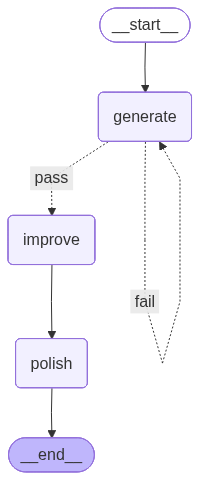

In [10]:
graph = StateGraph(State)

# adding the nodes
graph.add_node("generate",generate_story)
graph.add_node("improve",improved_story)
graph.add_node("polish",polish_story)

# adding the edges
graph.add_edge(START,"generate")
graph.add_conditional_edges("generate",check_conflict,{"pass":"improve","fail":"generate"})
graph.add_edge("improve","polish")
graph.add_edge("polish",END)

graph_builder = graph.compile()
visualize_graph = graph_builder.get_graph().draw_mermaid_png()
display(Image(visualize_graph))

In [12]:
msg = graph_builder.invoke({"topic":"MS Dhoni"})
print(msg)

{'topic': 'MS Dhoni', 'story': 'As the world watched him bid farewell to international cricket, MS Dhoni embarked on a mysterious journey to his hometown in Ranchi, where he uncovered a long-lost legacy that would forever change the course of his life.', 'improved_story': "As the world watched with a mix of nostalgia and awe, Mahendra Singh Dhoni stood at the threshold of a new chapter in his life, bidding a bittersweet farewell to the international cricket arena. The sound of applause and cheers still lingered in the air as he smiled and waved, his eyes glistening with a hint of melancholy. The once-invincible wicket-keeper batsman, who had left an indelible mark on the game, was finally hanging up his cricket boots.\n\nAs the crowd dispersed and the cameras stopped rolling, Dhoni slipped away from the noise and chaos of the stadium. He boarded a private plane, its sleek exterior gleaming in the fading light of day, and took off into the sky. The roar of the engines and the rush of wi